<a href="https://colab.research.google.com/github/poornimababu2021-maker/data-analysis/blob/main/AI_Car_Price_pdtn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load the** **Dataset**

In [3]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Explore the Dataset**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


**Data Cleaning**

In [7]:
df = df.drop_duplicates()

In [8]:
df = df.dropna()

**Data Visualization**

Price Distribution

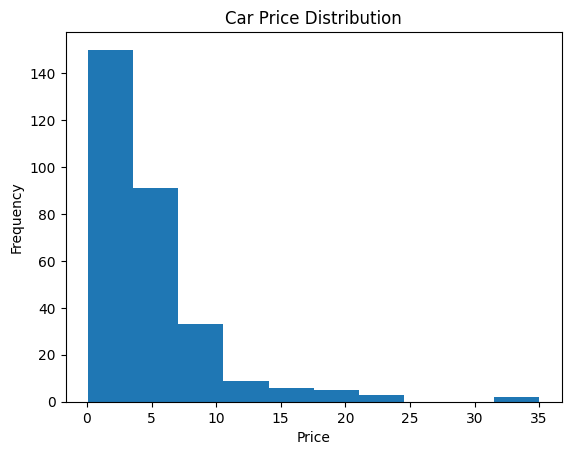

In [9]:
plt.hist(df['Selling_Price'])
plt.title("Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Fuel Type vs Price

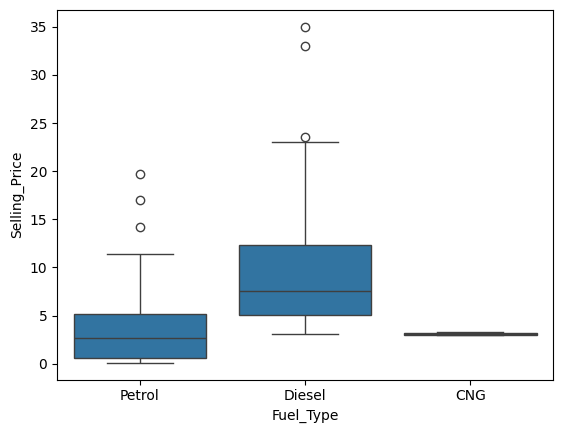

In [10]:
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.show()

Year vs Price

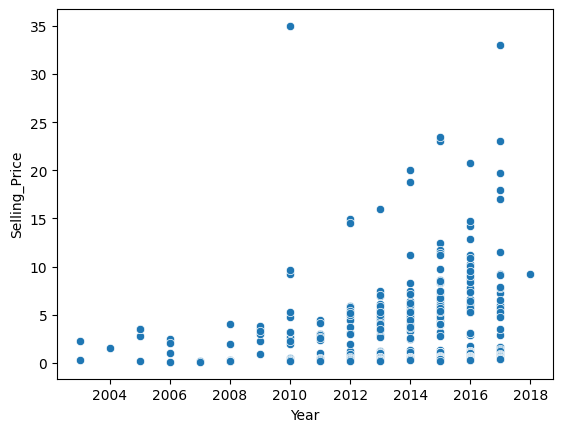

In [11]:
sns.scatterplot(x="Year", y="Selling_Price", data=df)
plt.show()

**Feature Engineering**

In [12]:
df['Car_Age'] = 2024 - df['Year']

**Creating Recommendation Logic**

In [14]:
df['Score'] = (10 - df['Selling_Price']) + (df['Year'] - 2010) - (df['Driven_kms']/10000)

In [15]:
df = df.sort_values(by='Score', ascending=False)

**Take User Input**

In [29]:
budget = float(input("Enter your budget (in lakhs): "))
fuel = input("Enter preferred fuel type (Petrol/Diesel/CNG): ")

Enter your budget (in lakhs): 7
Enter preferred fuel type (Petrol/Diesel/CNG): petrol


**Filter Cars Based on Preferences**

In [30]:
recommended = df[
    (df['Selling_Price'] <= budget) &
    (df['Fuel_Type'].str.lower() == fuel.lower())
]

**Display Recommended Cars**

In [31]:
top_cars = recommended.head(5)

print("Top Recommended Cars for You:\n")

if not top_cars.empty:
    print(top_cars[['Car_Name','Year','Selling_Price','Driven_kms']])
else:
    print("No cars found matching your criteria. Try adjusting your budget or fuel type.")

Top Recommended Cars for You:

              Car_Name  Year  Selling_Price  Driven_kms
173          Activa 4g  2017           0.40        1300
159    Honda Activa 4G  2017           0.45        4000
155    Honda Activa 4G  2017           0.48        4300
126  Bajaj Avenger 220  2017           0.90        1300
132  Bajaj Avenger 220  2017           0.75        3500


**Visualize Recommended Cars**

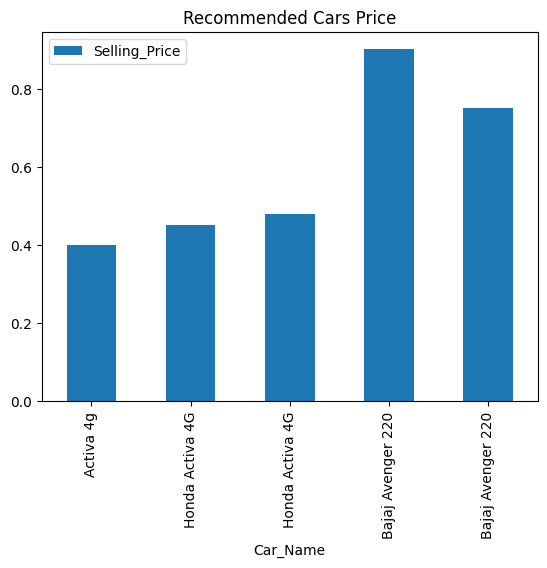

In [32]:
top_cars.plot(x='Car_Name', y='Selling_Price', kind='bar')
plt.title("Recommended Cars Price")
plt.show()



**CONCLUSION**

The AI Car Price Recommendation System analyzes car data and suggests the best cars based on user preferences such as budget and fuel type. The system ranks vehicles using a scoring algorithm considering price, age, and usage, helping users choose the most suitable car.